# SkyView Aerial Landscape — Tree-Based Methods Classifier
**STA6704 Group Project**

This notebook is the tree-based counterpart to the CNN training notebook. It uses the same Kaggle dataset and train/validation/test proportions, then compares several tree-based methods:

- **Single classification tree** — interpretable baseline.
- **Bagged trees** — many bootstrapped trees using all features; usually higher tree correlation.
- **Random forest** — bootstrapped trees with random feature subsets; designed to decorrelate trees.
- **Extra Trees** — very randomized trees; usually the most decorrelated tree ensemble here.
- **Histogram Gradient Boosting** — sequential ensemble learning where later trees correct earlier errors.

Because tree models do not naturally consume images the way CNNs do, this notebook converts each image into fixed-length numeric features: color summaries, color histograms, simple texture/edge features, and a small grayscale thumbnail.

---
## 1. Imports

In [1]:
import os
import random
import pathlib
import time
import copy
import warnings
import collections
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from PIL import Image, ImageOps

import torch
from torch.utils.data import random_split
from torchvision import datasets

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance

import kagglehub

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Imports OK.")

Imports OK.


---
## 2. Reproducibility and CPU Check

Tree-based methods run on the CPU in scikit-learn. A GPU is not required for this notebook.

In [2]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

RANDOM_SEED = 42
seed_everything(RANDOM_SEED)

print(f"Random seed : {RANDOM_SEED}")
print(f"CPU cores   : {os.cpu_count()}")

Random seed : 42
CPU cores   : 16


---
## 3. HYPERPARAMETERS ← adjust here

For a quick test run, set `MAX_IMAGES_PER_CLASS` to something like `200`. For the final project run, leave it as `None`.

In [3]:
# ── Data ──────────────────────────────────────────────────────────────────────
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15
# Test split is computed as the remaining fraction.

# Use "cnn_random_split" to match the CNN notebook's random_split behavior.
# Use "stratified" if you want each split to preserve class proportions.
SPLIT_MODE = "cnn_random_split"   # "cnn_random_split" | "stratified"

# Optional local override. Leave as None to download/find the Kaggle dataset.
LOCAL_DATA_ROOT = None            # example: r"C:\path\to\skyview-dataset"

# For faster debugging. Set to None for final run.
MAX_IMAGES_PER_CLASS = None       # example: 200

# ── Feature extraction ────────────────────────────────────────────────────────
FEATURE_IMAGE_SIZE = 128          # image is resized to this before feature extraction
LOWRES_SIZE        = 16           # grayscale thumbnail size; 16 -> 256 low-res pixel features
COLOR_HIST_BINS    = 16           # per-channel RGB histogram bins
CACHE_FEATURES     = True         # save/load extracted features to avoid repeating work

# ── Models ────────────────────────────────────────────────────────────────────
N_ESTIMATORS       = 300          # try 100 for speed, 500+ for final run
N_JOBS             = -1           # -1 uses all available CPU cores where sklearn supports it
CV_FOLDS           = 3            # kept for possible tuning cells

# ── Diagnostics ───────────────────────────────────────────────────────────────
TREE_AGREEMENT_SAMPLE_SIZE = 500  # sample of validation rows used for tree-diversity check
TOP_FEATURES_TO_PLOT       = 25

print("Hyperparameters set.")

Hyperparameters set.


---
## 4. Download Dataset and Locate Image Root

This mirrors the CNN notebook's Kaggle dataset call.

In [4]:
if LOCAL_DATA_ROOT is None:
    dataset_path = kagglehub.dataset_download("ankit1743/skyview-an-aerial-landscape-dataset")
    root = pathlib.Path(dataset_path)
else:
    root = pathlib.Path(LOCAL_DATA_ROOT)

# Step into a single subdirectory if the Kaggle download wraps the data.
subdirs = [p for p in root.iterdir() if p.is_dir()]
if len(subdirs) == 1:
    root = subdirs[0]

image_dataset = datasets.ImageFolder(root=str(root))
CLASS_NAMES = image_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Image root   : {root}")
print(f"Num classes  : {NUM_CLASSES}")
print(f"Classes      : {CLASS_NAMES}")
print(f"Total images : {len(image_dataset)}")

Image root   : C:\Users\2beto\.cache\kagglehub\datasets\ankit1743\skyview-an-aerial-landscape-dataset\versions\1\Aerial_Landscapes
Num classes  : 15
Classes      : ['Agriculture', 'Airport', 'Beach', 'City', 'Desert', 'Forest', 'Grassland', 'Highway', 'Lake', 'Mountain', 'Parking', 'Port', 'Railway', 'Residential', 'River']
Total images : 12000


---
## 5. Build Image Index and Train/Val/Test Split

The default `SPLIT_MODE = "cnn_random_split"` is designed to be directly comparable to the CNN notebook: same split proportions and the same `torch.random_split` mechanism.

In [5]:
from sklearn.model_selection import train_test_split

all_paths  = np.array([str(path) for path, label in image_dataset.samples])
all_labels = np.array([label for path, label in image_dataset.samples])

index_df = pd.DataFrame({
    "path": all_paths,
    "label": all_labels,
    "class_name": [CLASS_NAMES[y] for y in all_labels],
})

# Optional balanced subsample for development/debugging.
if MAX_IMAGES_PER_CLASS is not None:
    index_df = (
        index_df
        .groupby("label", group_keys=False)
        .apply(lambda d: d.sample(min(len(d), MAX_IMAGES_PER_CLASS), random_state=RANDOM_SEED))
        .sample(frac=1, random_state=RANDOM_SEED)
        .reset_index(drop=True)
    )
    all_paths  = index_df["path"].to_numpy()
    all_labels = index_df["label"].to_numpy()
    print(f"Using a development subset: {len(index_df)} images.")

total   = len(index_df)
n_train = int(total * TRAIN_SPLIT)
n_val   = int(total * VAL_SPLIT)
n_test  = total - n_train - n_val

if SPLIT_MODE == "cnn_random_split":
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    all_indices = list(range(total))
    train_subset, val_subset, test_subset = random_split(
        all_indices, [n_train, n_val, n_test], generator=generator
    )
    train_idx = np.array(train_subset.indices)
    val_idx   = np.array(val_subset.indices)
    test_idx  = np.array(test_subset.indices)

elif SPLIT_MODE == "stratified":
    train_idx, temp_idx = train_test_split(
        np.arange(total),
        train_size=n_train,
        random_state=RANDOM_SEED,
        stratify=all_labels,
    )
    relative_val_size = n_val / (n_val + n_test)
    val_idx, test_idx = train_test_split(
        temp_idx,
        train_size=relative_val_size,
        random_state=RANDOM_SEED,
        stratify=all_labels[temp_idx],
    )

else:
    raise ValueError("SPLIT_MODE must be either 'cnn_random_split' or 'stratified'.")

split_lookup = np.full(total, "unused", dtype=object)
split_lookup[train_idx] = "train"
split_lookup[val_idx] = "val"
split_lookup[test_idx] = "test"
index_df["split"] = split_lookup

print(f"Split mode         : {SPLIT_MODE}")
print(f"Train / Val / Test : {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

display(pd.crosstab(index_df["class_name"], index_df["split"], margins=True))

Split mode         : cnn_random_split
Train / Val / Test : 8400 / 1800 / 1800


split,test,train,val,All
class_name,,,,
Agriculture,122,561,117,800
Airport,112,557,131,800
Beach,137,548,115,800
City,120,565,115,800
Desert,120,570,110,800
Forest,100,579,121,800
Grassland,128,545,127,800
Highway,124,570,106,800
Lake,130,537,133,800


---
## 6. Feature Extraction

The models below use numeric image descriptors rather than raw image tensors. These features are intentionally simple so the analysis remains tree-based and explainable.

Feature groups:
- RGB channel statistics
- RGB color histograms
- Grayscale texture/edge measurements
- Low-resolution grayscale thumbnail pixels

In [6]:
def _pil_resample_filter():
    # Compatibility across Pillow versions.
    if hasattr(Image, "Resampling"):
        return Image.Resampling.BILINEAR
    return Image.BILINEAR


def extract_image_features(
    image_path: str,
    image_size: int = FEATURE_IMAGE_SIZE,
    lowres_size: int = LOWRES_SIZE,
    hist_bins: int = COLOR_HIST_BINS,
) -> Tuple[np.ndarray, List[str]]:
    # Return a 1D feature vector and feature names for one image.
    img = Image.open(image_path)
    img = ImageOps.exif_transpose(img).convert("RGB")
    img = img.resize((image_size, image_size), _pil_resample_filter())

    arr = np.asarray(img).astype(np.float32) / 255.0
    gray = (
        0.299 * arr[:, :, 0] +
        0.587 * arr[:, :, 1] +
        0.114 * arr[:, :, 2]
    )

    feats = []
    names = []

    # RGB channel stats.
    channels = ["R", "G", "B"]
    for c, cname in enumerate(channels):
        x = arr[:, :, c].ravel()
        stats = {
            "mean": np.mean(x),
            "std": np.std(x),
            "min": np.min(x),
            "max": np.max(x),
            "p10": np.percentile(x, 10),
            "p50": np.percentile(x, 50),
            "p90": np.percentile(x, 90),
        }
        for stat_name, value in stats.items():
            feats.append(value)
            names.append(f"rgb_{cname}_{stat_name}")

    # RGB color histograms.
    for c, cname in enumerate(channels):
        hist, _ = np.histogram(arr[:, :, c], bins=hist_bins, range=(0, 1), density=False)
        hist = hist.astype(np.float32)
        hist = hist / max(hist.sum(), 1.0)
        feats.extend(hist.tolist())
        names.extend([f"rgb_{cname}_hist_{i:02d}" for i in range(hist_bins)])

    # Grayscale stats.
    g = gray.ravel()
    gray_stats = {
        "gray_mean": np.mean(g),
        "gray_std": np.std(g),
        "gray_min": np.min(g),
        "gray_max": np.max(g),
        "gray_p10": np.percentile(g, 10),
        "gray_p50": np.percentile(g, 50),
        "gray_p90": np.percentile(g, 90),
    }
    for stat_name, value in gray_stats.items():
        feats.append(value)
        names.append(stat_name)

    # Simple gradient/edge features.
    gy, gx = np.gradient(gray)
    grad_mag = np.sqrt(gx**2 + gy**2)
    edge_threshold = np.percentile(grad_mag, 75)
    edge_density = np.mean(grad_mag > edge_threshold)

    texture_stats = {
        "grad_mean": np.mean(grad_mag),
        "grad_std": np.std(grad_mag),
        "grad_p90": np.percentile(grad_mag, 90),
        "edge_density_q75": edge_density,
    }
    for stat_name, value in texture_stats.items():
        feats.append(value)
        names.append(stat_name)

    # Low-res grayscale thumbnail features.
    gray_img = Image.fromarray(np.uint8(np.clip(gray * 255, 0, 255)), mode="L")
    gray_small = gray_img.resize((lowres_size, lowres_size), _pil_resample_filter())
    low = np.asarray(gray_small).astype(np.float32).ravel() / 255.0
    feats.extend(low.tolist())
    names.extend([f"lowgray_{r:02d}_{c:02d}" for r in range(lowres_size) for c in range(lowres_size)])

    return np.asarray(feats, dtype=np.float32), names


# Smoke test on one image.
test_features, feature_names = extract_image_features(all_paths[0])
print(f"Feature count: {len(feature_names)}")
print(f"First 10 features: {feature_names[:10]}")

Feature count: 336
First 10 features: ['rgb_R_mean', 'rgb_R_std', 'rgb_R_min', 'rgb_R_max', 'rgb_R_p10', 'rgb_R_p50', 'rgb_R_p90', 'rgb_G_mean', 'rgb_G_std', 'rgb_G_min']


In [7]:
def maybe_tqdm(iterable, **kwargs):
    try:
        from tqdm.auto import tqdm
        return tqdm(iterable, **kwargs)
    except Exception:
        return iterable


cache_name = (
    f"skyview_tree_features_"
    f"n{len(all_paths)}_img{FEATURE_IMAGE_SIZE}_low{LOWRES_SIZE}_hist{COLOR_HIST_BINS}_seed{RANDOM_SEED}.npz"
)
cache_path = pathlib.Path(cache_name)

loaded_from_cache = False
if CACHE_FEATURES and cache_path.exists():
    cached = np.load(cache_path, allow_pickle=True)
    cached_paths = cached["paths"].astype(str)
    if len(cached_paths) == len(all_paths) and np.array_equal(cached_paths, all_paths.astype(str)):
        X_all = cached["X"].astype(np.float32)
        y_all = cached["y"].astype(int)
        feature_names = cached["feature_names"].astype(str).tolist()
        loaded_from_cache = True
        print(f"Loaded cached features from {cache_path}")
    else:
        print("Found a feature cache, but it does not match the current dataset/index. Re-extracting.")

if not loaded_from_cache:
    t0 = time.time()
    X_rows = []
    bad_files = []
    feature_names = None

    for p in maybe_tqdm(all_paths, desc="Extracting image features"):
        try:
            feats, names = extract_image_features(p)
            X_rows.append(feats)
            if feature_names is None:
                feature_names = names
        except Exception as e:
            # Keep the run from crashing if one image is corrupt.
            bad_files.append((p, repr(e)))
            X_rows.append(np.full_like(test_features, np.nan, dtype=np.float32))

    X_all = np.vstack(X_rows).astype(np.float32)
    y_all = all_labels.astype(int)

    # If any files failed, fill missing features with column medians.
    if bad_files:
        print(f"Warning: {len(bad_files)} files failed during feature extraction.")
        X_df_tmp = pd.DataFrame(X_all, columns=feature_names)
        X_df_tmp = X_df_tmp.fillna(X_df_tmp.median(numeric_only=True))
        X_all = X_df_tmp.to_numpy(dtype=np.float32)

    if CACHE_FEATURES:
        np.savez_compressed(
            cache_path,
            X=X_all,
            y=y_all,
            paths=all_paths.astype(str),
            feature_names=np.array(feature_names, dtype=object),
        )
        print(f"Saved feature cache to {cache_path}")

    print(f"Feature extraction took {(time.time() - t0) / 60:.2f} minutes.")

print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")

Extracting image features:   0%|          | 0/12000 [00:00<?, ?it/s]

Saved feature cache to skyview_tree_features_n12000_img128_low16_hist16_seed42.npz
Feature extraction took 0.85 minutes.
X_all shape: (12000, 336)
y_all shape: (12000,)


---
## 7. Prepare Train/Validation/Test Matrices

In [8]:
X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val,   y_val   = X_all[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

feature_df = pd.DataFrame(X_train, columns=feature_names)
display(feature_df.describe().T.head(12))

X_train : (8400, 336)
X_val   : (1800, 336)
X_test  : (1800, 336)


,count,mean,std,min,25%,50%,75%,max
rgb_R_mean,8400.0,0.379000,0.155173,0.045289,0.270670,0.352434,0.451687,0.967681
rgb_R_std,8400.0,0.123523,0.056192,0.009619,0.084425,0.122573,0.157724,0.394963
rgb_R_min,8400.0,0.106608,0.125487,0.000000,0.031373,0.066667,0.130392,0.913725
rgb_R_max,8400.0,0.832144,0.178903,0.105882,0.749020,0.898039,0.972549,1.000000
rgb_R_p10,8400.0,0.233058,0.156722,0.000000,0.133333,0.192157,0.278431,0.945098
rgb_R_p50,8400.0,0.366078,0.167153,0.011765,0.243137,0.333333,0.447059,0.980392
rgb_R_p90,8400.0,0.542529,0.181335,0.078431,0.415686,0.537255,0.658824,1.000000
rgb_G_mean,8400.0,0.393424,0.126297,0.054465,0.304701,0.375384,0.461729,0.889378
rgb_G_std,8400.0,0.110701,0.049414,0.008218,0.074865,0.109024,0.143085,0.317402
rgb_G_min,8400.0,0.132479,0.114947,0.000000,0.050980,0.098039,0.180392,0.756863


---
## 8. Define Tree-Based Models

The ensemble setup is intentionally organized around the project language:

- **Correlated tree ensemble:** bagging uses all features at each split, so individual trees can be more similar/correlated.
- **Decorrelated tree ensembles:** random forests and Extra Trees inject randomness through feature subsets and/or random thresholds.
- **Boosting:** trees are built sequentially instead of independently.

In [9]:
def make_bagging_classifier(base_tree, n_estimators=N_ESTIMATORS):
    # Handle sklearn versions that use estimator= vs base_estimator=.
    kwargs = dict(
        n_estimators=n_estimators,
        max_samples=0.80,
        bootstrap=True,
        oob_score=True,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
    )
    try:
        return BaggingClassifier(estimator=base_tree, **kwargs)
    except TypeError:
        return BaggingClassifier(base_estimator=base_tree, **kwargs)


p = X_train.shape[1]

single_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_SEED,
)

bagged_trees = make_bagging_classifier(
    DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    )
)

random_forest = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_features="sqrt",              # key random-forest decorrelation step
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    class_weight="balanced_subsample",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

extra_trees = ExtraTreesClassifier(
    n_estimators=N_ESTIMATORS,
    max_features="sqrt",
    min_samples_leaf=1,
    bootstrap=False,
    class_weight="balanced",
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
)

hist_gradient_boosting = HistGradientBoostingClassifier(
    max_iter=250,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.01,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_SEED,
)

models = {
    "Dummy: Most Frequent": DummyClassifier(strategy="most_frequent"),
    "Single Decision Tree": single_tree,
    "Bagged Trees (correlated)": bagged_trees,
    "Random Forest (decorrelated)": random_forest,
    "Extra Trees (highly decorrelated)": extra_trees,
    "Hist Gradient Boosting": hist_gradient_boosting,
}

models

{'Dummy: Most Frequent': DummyClassifier(strategy='most_frequent'),
 'Single Decision Tree': DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=2,
                        random_state=42),
 'Bagged Trees (correlated)': BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    random_state=42),
                   max_samples=0.8, n_estimators=300, n_jobs=-1, oob_score=True,
                   random_state=42),
 'Random Forest (decorrelated)': RandomForestClassifier(class_weight='balanced_subsample', n_estimators=300,
                        n_jobs=-1, oob_score=True, random_state=42),
 'Extra Trees (highly decorrelated)': ExtraTreesClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                      random_state=42),
 'Hist Gradient Boosting': HistGradientBoostingClassifier(early_stopping=True, l2_regularization=0.01,
                                learning_rate=0.05, max_iter=250,
   

---
## 9. Train and Evaluate Models

We fit on the training set, use validation results for model comparison, then report test results.

In [10]:
def evaluate_predictions(y_true, y_pred) -> Dict[str, float]:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }


def fit_and_evaluate(name: str, model):
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_seconds = time.time() - t0

    train_pred = model.predict(X_train)
    val_pred   = model.predict(X_val)
    test_pred  = model.predict(X_test)

    row = {
        "model": name,
        "fit_seconds": fit_seconds,
        "oob_score": getattr(model, "oob_score_", np.nan),
    }

    for split_name, yt, yp in [
        ("train", y_train, train_pred),
        ("val", y_val, val_pred),
        ("test", y_test, test_pred),
    ]:
        metrics = evaluate_predictions(yt, yp)
        row.update({f"{split_name}_{k}": v for k, v in metrics.items()})

    return model, row, {"train": train_pred, "val": val_pred, "test": test_pred}


fitted_models = {}
predictions = {}
rows = []

for name, model in models.items():
    print(f"\nFitting: {name}")
    fitted, row, preds = fit_and_evaluate(name, model)
    fitted_models[name] = fitted
    predictions[name] = preds
    rows.append(row)
    print(
        f"  val acc={row['val_accuracy']:.4f}, "
        f"val macro-F1={row['val_macro_f1']:.4f}, "
        f"test acc={row['test_accuracy']:.4f}, "
        f"time={row['fit_seconds']:.1f}s"
    )

results_df = (
    pd.DataFrame(rows)
    .sort_values("val_macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(results_df)


Fitting: Dummy: Most Frequent
  val acc=0.0644, val macro-F1=0.0081, test acc=0.0533, time=0.0s

Fitting: Single Decision Tree
  val acc=0.5050, val macro-F1=0.5028, test acc=0.4933, time=2.3s

Fitting: Bagged Trees (correlated)
  val acc=0.6700, val macro-F1=0.6644, test acc=0.6456, time=38.9s

Fitting: Random Forest (decorrelated)
  val acc=0.6472, val macro-F1=0.6381, test acc=0.6439, time=3.0s

Fitting: Extra Trees (highly decorrelated)
  val acc=0.6278, val macro-F1=0.6168, test acc=0.6178, time=0.8s

Fitting: Hist Gradient Boosting


  File "c:\Users\2beto\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\2beto\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\2beto\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\2beto\anaconda3\Lib\subprocess.

  val acc=0.7183, val macro-F1=0.7168, test acc=0.7000, time=26.9s


,model,fit_seconds,oob_score,train_accuracy,train_balanced_accuracy,train_macro_f1,train_weighted_f1,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,Hist Gradient Boosting,26.917992,NaN,0.954286,0.954098,0.954180,0.954308,0.718333,0.716184,0.716804,0.719133,0.700000,0.703910,0.704076,0.701666
1,Bagged Trees (correlated),38.893410,0.654762,1.000000,1.000000,1.000000,1.000000,0.670000,0.668074,0.664417,0.665905,0.645556,0.650669,0.646020,0.643199
2,Random Forest (decorrelated),2.953335,0.644524,1.000000,1.000000,1.000000,1.000000,0.647222,0.644781,0.638122,0.640440,0.643889,0.651361,0.641973,0.638592
3,Extra Trees (highly decorrelated),0.821980,NaN,1.000000,1.000000,1.000000,1.000000,0.627778,0.624993,0.616824,0.619267,0.617778,0.626741,0.614378,0.609599
4,Single Decision Tree,2.271481,NaN,0.915833,0.916544,0.915853,0.916122,0.505000,0.504077,0.502820,0.503902,0.493333,0.499034,0.497440,0.491850
5,Dummy: Most Frequent,0.001269,NaN,0.070000,0.066667,0.008723,0.009159,0.064444,0.066667,0.008072,0.007803,0.053333,0.066667,0.006751,0.005401


---
## 10. Model Comparison Plots

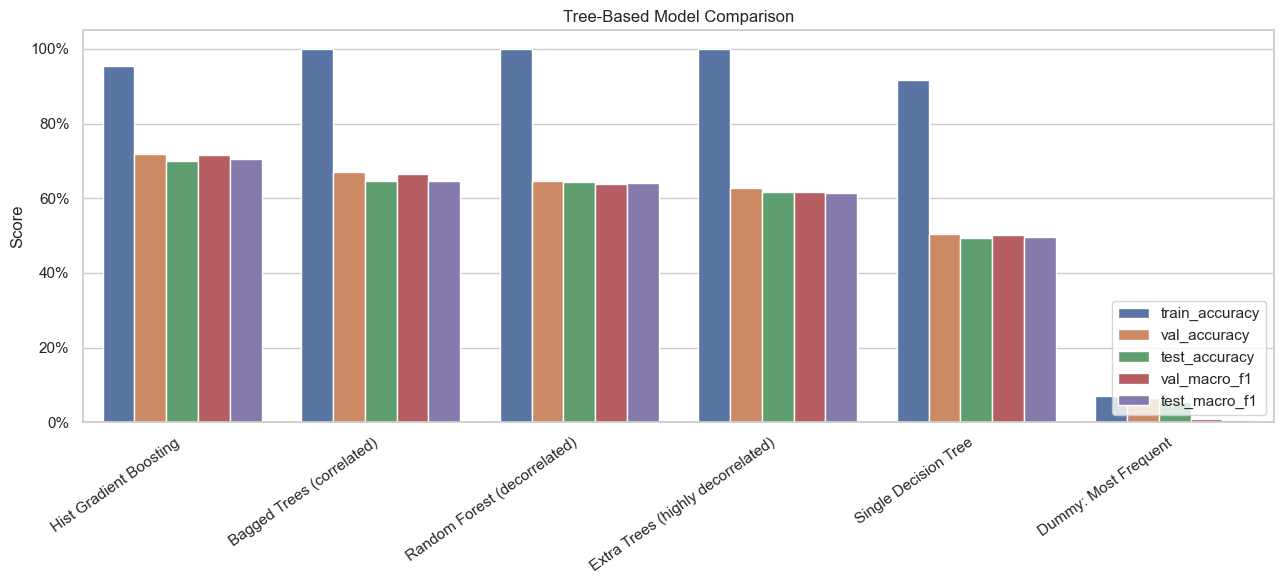

In [11]:
plot_df = results_df.melt(
    id_vars="model",
    value_vars=["train_accuracy", "val_accuracy", "test_accuracy", "val_macro_f1", "test_macro_f1"],
    var_name="metric",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric", ax=ax)
ax.set_title("Tree-Based Model Comparison")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
## 11. Best Model: Test Classification Report and Confusion Matrix

Best model by validation macro-F1: Hist Gradient Boosting

              precision    recall  f1-score   support

 Agriculture       0.63      0.67      0.65       122
     Airport       0.49      0.56      0.53       112
       Beach       0.90      0.85      0.87       137
        City       0.72      0.69      0.70       120
      Desert       0.96      0.94      0.95       120
      Forest       0.84      0.87      0.85       100
   Grassland       0.89      0.91      0.90       128
     Highway       0.50      0.52      0.51       124
        Lake       0.71      0.61      0.65       130
    Mountain       0.70      0.65      0.67       137
     Parking       0.79      0.83      0.81        96
        Port       0.83      0.79      0.81       114
     Railway       0.46      0.55      0.50       112
 Residential       0.75      0.70      0.73       115
       River       0.45      0.41      0.43       133

    accuracy                           0.70      1800
   macro avg       0.

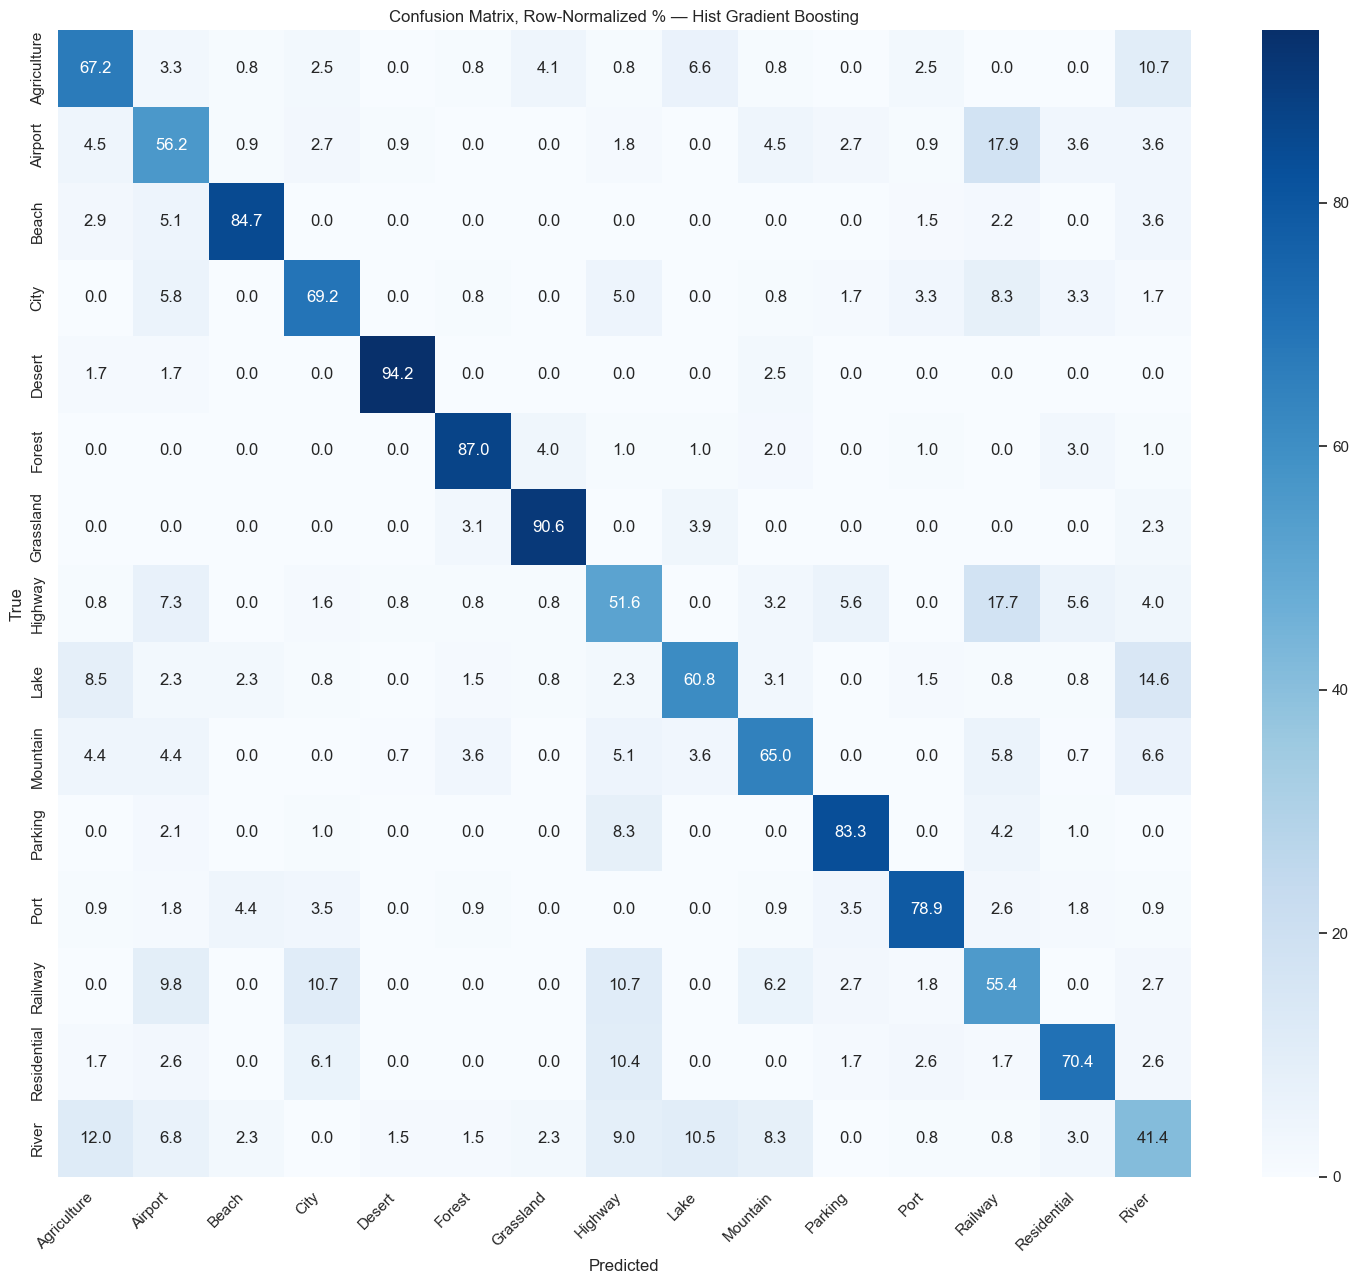

In [12]:
best_name = results_df.loc[0, "model"]
best_model = fitted_models[best_name]
best_test_pred = predictions[best_name]["test"]

print(f"Best model by validation macro-F1: {best_name}\n")
print(classification_report(y_test, best_test_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, best_test_pred)
cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES - 2)))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
)
ax.set_title(f"Confusion Matrix, Row-Normalized % — {best_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 12. Feature Importance

This section helps explain which image features the tree methods used most. For standard tree ensembles, impurity-based importance is used. If unavailable, the notebook falls back to permutation importance on the validation set.

This model does not expose feature_importances_; running permutation importance.
Importance type: permutation macro-F1 decrease


,feature,importance
0,grad_mean,0.148676
1,grad_std,0.123274
2,rgb_R_p10,0.050337
3,grad_p90,0.029167
4,rgb_G_hist_01,0.027985
5,rgb_B_max,0.027089
6,rgb_B_p90,0.026281
7,rgb_R_std,0.021640
8,rgb_G_min,0.016522
9,rgb_R_hist_06,0.014942


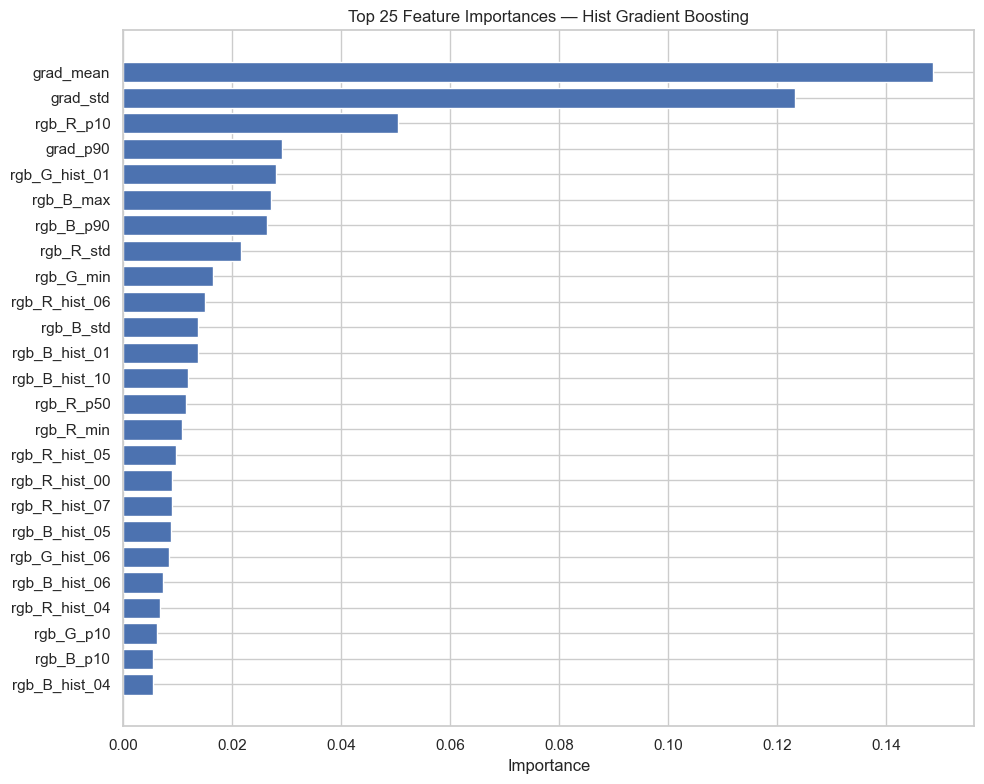

In [13]:
def bagging_feature_importances(model, n_features: int) -> Optional[np.ndarray]:
    # Average feature importances from BaggingClassifier base estimators.
    if not hasattr(model, "estimators_"):
        return None
    importances = []
    for i, est in enumerate(model.estimators_):
        if not hasattr(est, "feature_importances_"):
            continue

        # Bagging may train estimators on feature subsets. Handle either case.
        imp = np.zeros(n_features, dtype=float)
        if hasattr(model, "estimators_features_"):
            feats = model.estimators_features_[i]
            imp[feats] = est.feature_importances_
        else:
            imp = est.feature_importances_
        importances.append(imp)

    if not importances:
        return None
    return np.mean(importances, axis=0)


def get_feature_importance(model, X_reference, y_reference):
    if hasattr(model, "feature_importances_"):
        return np.asarray(model.feature_importances_), "impurity"

    bag_imp = bagging_feature_importances(model, X_reference.shape[1])
    if bag_imp is not None:
        return bag_imp, "average impurity across bagged trees"

    print("This model does not expose feature_importances_; running permutation importance.")
    perm = permutation_importance(
        model,
        X_reference,
        y_reference,
        n_repeats=5,
        random_state=RANDOM_SEED,
        scoring="f1_macro",
        n_jobs=N_JOBS,
    )
    return perm.importances_mean, "permutation macro-F1 decrease"


importance_values, importance_type = get_feature_importance(best_model, X_val, y_val)

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Importance type: {importance_type}")
display(importance_df.head(TOP_FEATURES_TO_PLOT))

fig, ax = plt.subplots(figsize=(10, 8))
top_imp = importance_df.head(TOP_FEATURES_TO_PLOT).iloc[::-1]
ax.barh(top_imp["feature"], top_imp["importance"])
ax.set_title(f"Top {TOP_FEATURES_TO_PLOT} Feature Importances — {best_name}")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---
## 13. Correlated vs. Decorrelated Tree Diagnostic

This is a simple diversity check. It estimates how often pairs of individual trees in an ensemble make the same prediction on a validation sample.

Higher agreement means the trees behave more similarly. Bagging often has higher agreement because each tree can use all predictors; random forests and Extra Trees usually reduce agreement by injecting more randomness.

,model,avg_pairwise_tree_agreement,val_macro_f1,test_macro_f1
2,Extra Trees (highly decorrelated),0.265621,0.616824,0.614378
1,Random Forest (decorrelated),0.312930,0.638122,0.641973
0,Bagged Trees (correlated),0.401677,0.664417,0.646020


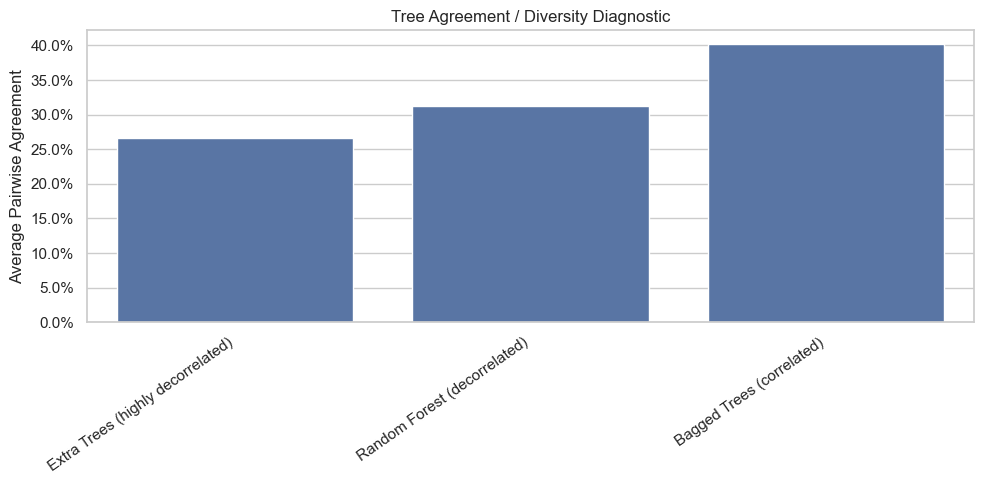

In [14]:
def average_pairwise_tree_agreement(model, X, max_trees: int = 75) -> float:
    if not hasattr(model, "estimators_"):
        return np.nan

    estimators = list(model.estimators_)[:max_trees]
    if len(estimators) < 2:
        return np.nan

    tree_preds = []

    for i, est in enumerate(estimators):
        try:
            if hasattr(model, "estimators_features_"):
                feats = model.estimators_features_[i]
                pred = est.predict(X[:, feats])
            else:
                pred = est.predict(X)
            tree_preds.append(pred)
        except Exception:
            continue

    if len(tree_preds) < 2:
        return np.nan

    tree_preds = np.asarray(tree_preds)
    agreements = []
    for i in range(tree_preds.shape[0]):
        for j in range(i + 1, tree_preds.shape[0]):
            agreements.append(np.mean(tree_preds[i] == tree_preds[j]))

    return float(np.mean(agreements))


rng = np.random.default_rng(RANDOM_SEED)
sample_size = min(TREE_AGREEMENT_SAMPLE_SIZE, len(X_val))
sample_idx = rng.choice(len(X_val), size=sample_size, replace=False)
X_agree = X_val[sample_idx]

agreement_rows = []
for name, model in fitted_models.items():
    agreement = average_pairwise_tree_agreement(model, X_agree)
    if not np.isnan(agreement):
        agreement_rows.append({
            "model": name,
            "avg_pairwise_tree_agreement": agreement,
            "val_macro_f1": results_df.set_index("model").loc[name, "val_macro_f1"],
            "test_macro_f1": results_df.set_index("model").loc[name, "test_macro_f1"],
        })

agreement_df = pd.DataFrame(agreement_rows).sort_values("avg_pairwise_tree_agreement")
display(agreement_df)

if not agreement_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=agreement_df, x="model", y="avg_pairwise_tree_agreement", ax=ax)
    ax.set_title("Tree Agreement / Diversity Diagnostic")
    ax.set_xlabel("")
    ax.set_ylabel("Average Pairwise Agreement")
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

---
## 14. Optional: Visualize a Small Decision Tree

A single tree is useful for explaining the idea, but it may be much less accurate than the ensembles. This cell fits a deliberately shallow tree for visualization.

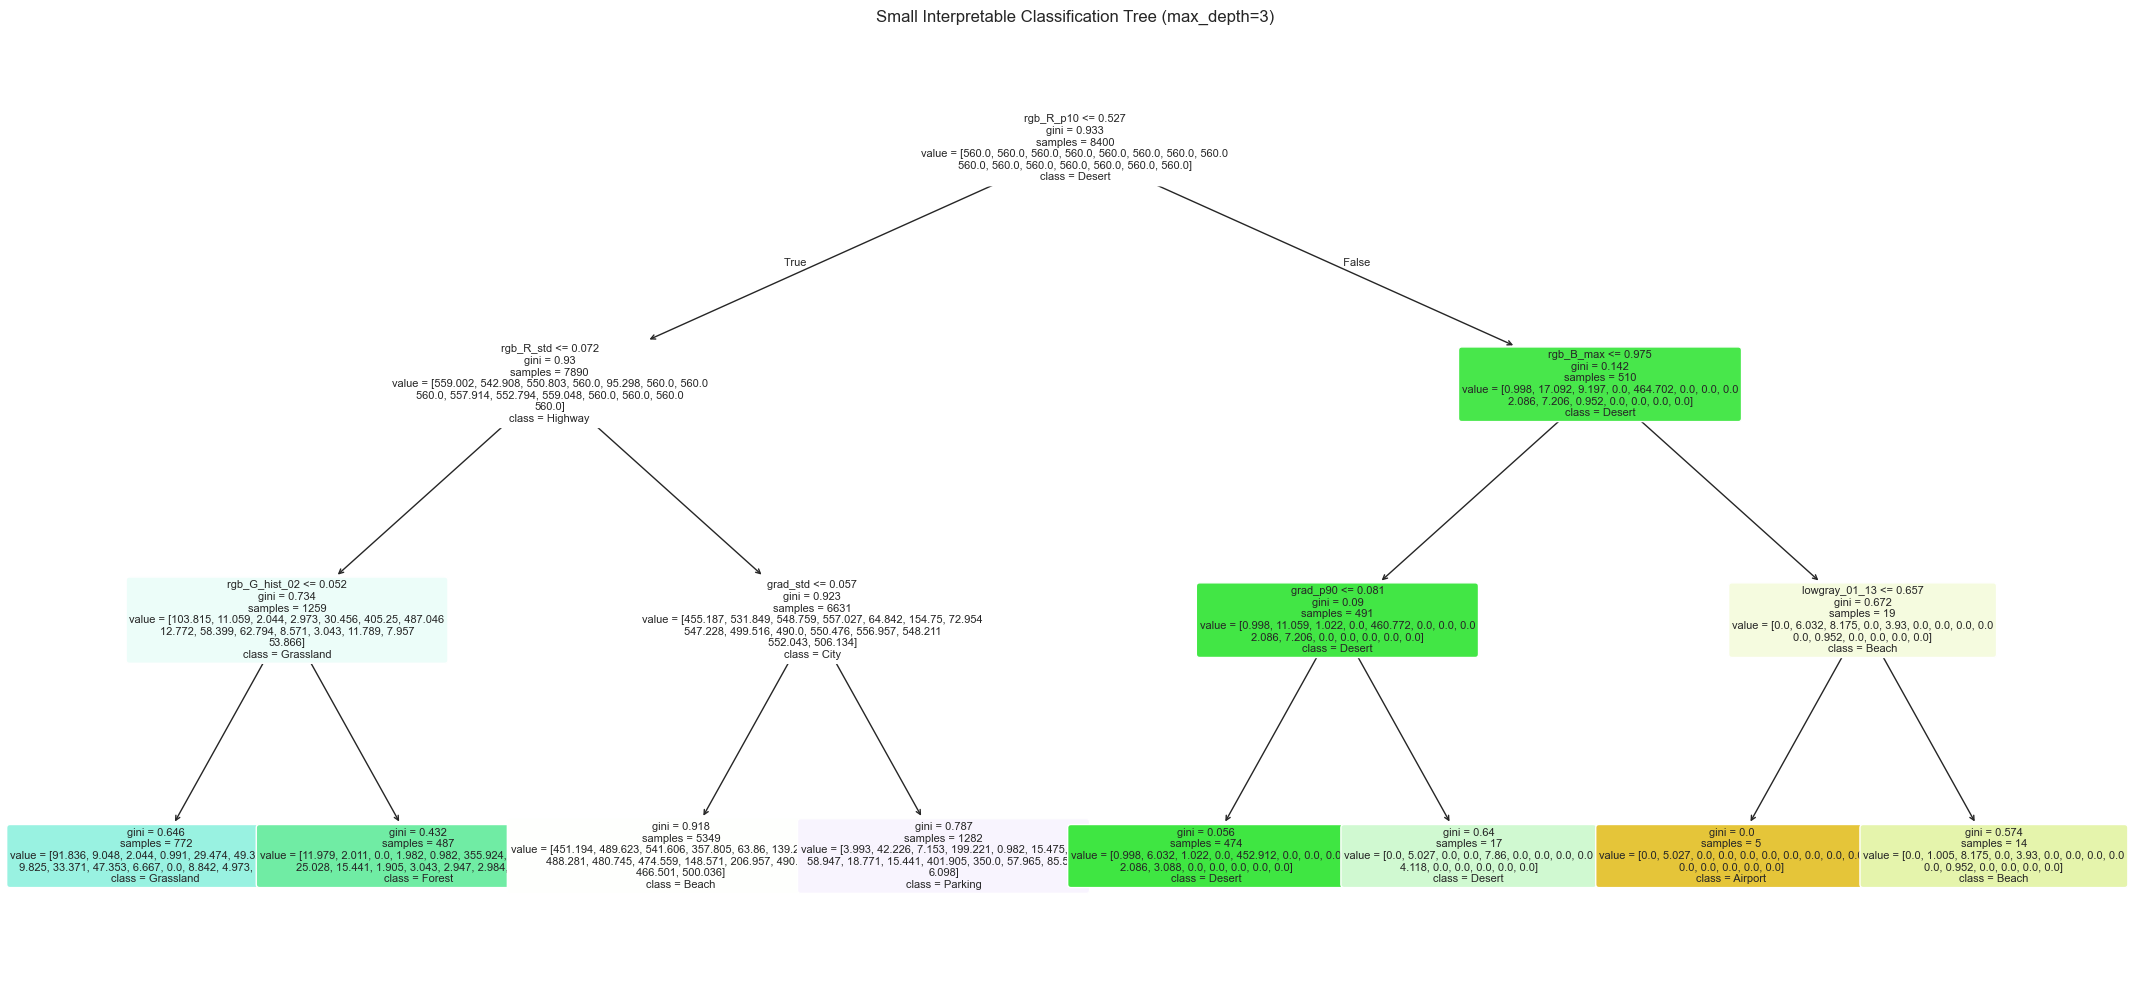

Small tree validation accuracy: 0.2561
Small tree validation macro-F1 : 0.1874


In [15]:
small_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_SEED,
)
small_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    small_tree,
    feature_names=feature_names,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Small Interpretable Classification Tree (max_depth=3)")
plt.tight_layout()
plt.show()

small_val_pred = small_tree.predict(X_val)
print(f"Small tree validation accuracy: {accuracy_score(y_val, small_val_pred):.4f}")
print(f"Small tree validation macro-F1 : {f1_score(y_val, small_val_pred, average='macro'):.4f}")

---
## 15. Save Results for the Final Report

In [16]:
OUTPUT_DIR = pathlib.Path("tree_based_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

results_path = OUTPUT_DIR / "tree_model_results.csv"
importance_path = OUTPUT_DIR / "tree_feature_importance.csv"
pred_path = OUTPUT_DIR / "tree_test_predictions.csv"

results_df.to_csv(results_path, index=False)
importance_df.to_csv(importance_path, index=False)

test_predictions_df = pd.DataFrame({
    "path": all_paths[test_idx],
    "true_label": y_test,
    "true_class": [CLASS_NAMES[i] for i in y_test],
    "pred_label": best_test_pred,
    "pred_class": [CLASS_NAMES[i] for i in best_test_pred],
    "correct": y_test == best_test_pred,
})
test_predictions_df.to_csv(pred_path, index=False)

print(f"Saved: {results_path}")
print(f"Saved: {importance_path}")
print(f"Saved: {pred_path}")

Saved: tree_based_outputs\tree_model_results.csv
Saved: tree_based_outputs\tree_feature_importance.csv
Saved: tree_based_outputs\tree_test_predictions.csv
